# Projeto FarmTech Solutions - Machine Learning

Este projeto tem como objetivo analisar dados de condições climáticas e de cultivo para prever o rendimento agrícola das safras.

Foram realizadas etapas de análise exploratória, clusterização e treinamento de modelos de regressão supervisionada, buscando identificar padrões nos dados e selecionar o melhor modelo preditivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [2]:
df = pd.read_csv('/content/sample_data/crop_yield.csv')

In [3]:
print('\nInformações do DataFrame (tipos de dados e contagem de não-nulos):')
df.info()


Informações do DataFrame (tipos de dados e contagem de não-nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


## Análise da Estrutura dos Dados

O dataset possui 156 registros e 6 colunas.

A variável "Crop" é categórica, enquanto as demais são numéricas.


In [4]:
print('Valores ausentes por coluna:')
print(df.isnull().sum())

Valores ausentes por coluna:
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64


Não há valores nulos


In [5]:
df.columns

Index(['Crop', 'Precipitation (mm day-1)',
       'Specific Humidity at 2 Meters (g/kg)',
       'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)',
       'Yield'],
      dtype='object')

In [6]:
df['Crop'].unique()
df['Crop'].nunique()

4

<Axes: xlabel='Crop'>

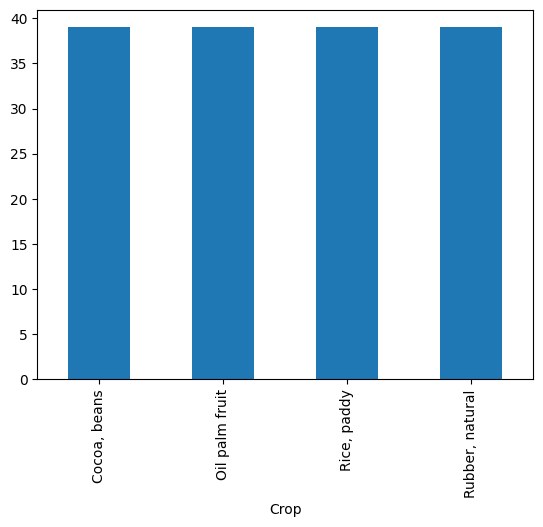

In [7]:
df['Crop'].value_counts().plot(kind='bar')

## Análise da distribuição das culturas

O dataset apresenta uma distribuição equilibrada entre as culturas, com aproximadamente a mesma quantidade de registros para cada uma.

Isso é positivo para a modelagem, pois evita viés nos dados.

In [8]:
X = df.drop('Yield', axis=1)
y = df['Yield']

## Separação das variáveis

As variáveis de entrada (X) foram separadas da variável alvo (y), sendo "Yield" a variável que será prevista pelo modelo.

In [10]:
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


## Análise das estatísticas descritivas

Observa-se que a variável "Yield" apresenta alta variabilidade, com grande diferença entre valores mínimos e máximos.

Já as variáveis climáticas apresentam baixa variação, indicando que são relativamente estáveis no dataset.

Isso sugere que outros fatores, como o tipo de cultura, podem ter grande influência no rendimento.

array([[<Axes: title={'center': 'Precipitation (mm day-1)'}>,
        <Axes: title={'center': 'Specific Humidity at 2 Meters (g/kg)'}>],
       [<Axes: title={'center': 'Relative Humidity at 2 Meters (%)'}>,
        <Axes: title={'center': 'Temperature at 2 Meters (C)'}>],
       [<Axes: title={'center': 'Yield'}>, <Axes: >]], dtype=object)

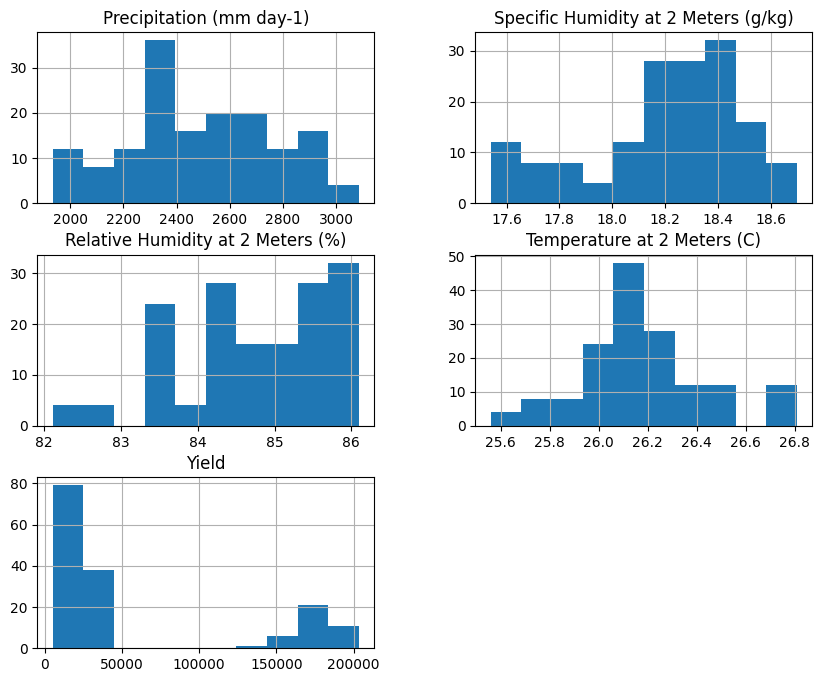

In [11]:
df.hist(figsize=(10,8))

## Análise dos histogramas

As variáveis climáticas apresentam distribuição concentrada, com pouca variação entre os valores.

Já a variável "Yield" apresenta uma distribuição assimétrica, com concentração em valores mais baixos e alguns valores muito altos, indicando possível presença de outliers.

,0
Precipitation (mm day-1),"Axes(0.125,0.653529;0.352273x0.226471)"
Specific Humidity at 2 Meters (g/kg),"Axes(0.547727,0.653529;0.352273x0.226471)"
Relative Humidity at 2 Meters (%),"Axes(0.125,0.381765;0.352273x0.226471)"
Temperature at 2 Meters (C),"Axes(0.547727,0.381765;0.352273x0.226471)"
Yield,"Axes(0.125,0.11;0.352273x0.226471)"


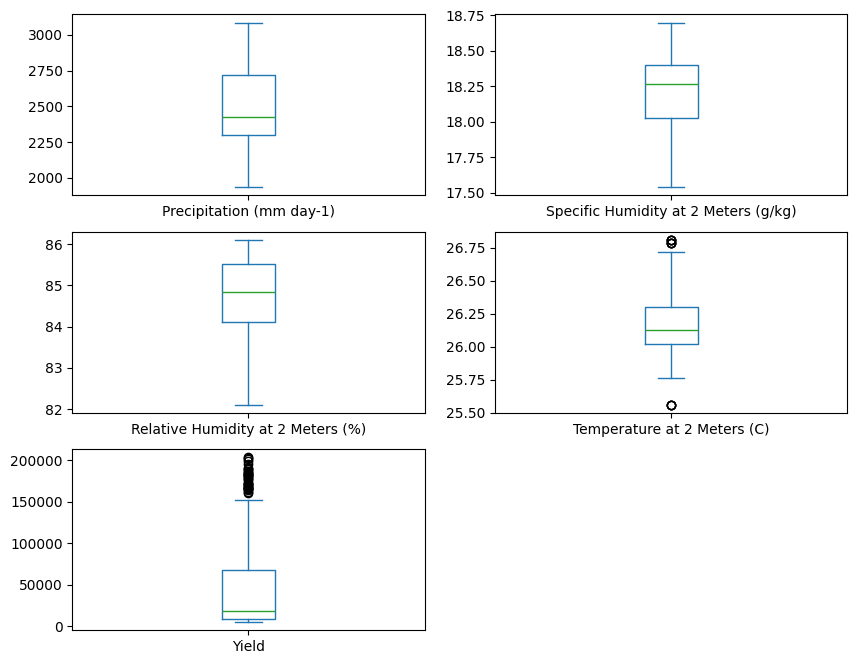

In [12]:
df.plot(kind='box', subplots=True, layout=(3,2), figsize=(10,8))

## Análise de outliers - PRIMEIRO PONTO

A variável "Yield" apresenta uma grande quantidade de outliers, com valores muito acima do padrão observado.

As variáveis climáticas, em geral, apresentam poucos ou nenhum outlier, indicando maior estabilidade nos dados.

Esses outliers podem impactar negativamente o desempenho dos modelos de Machine Learning.

> Adicionar aspas



In [15]:
df.corr(numeric_only=True)

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Precipitation (mm day-1),1.000000,0.488483,0.749464,-0.083927,0.018830
Specific Humidity at 2 Meters (g/kg),0.488483,1.000000,0.436687,0.699230,0.012651
Relative Humidity at 2 Meters (%),0.749464,0.436687,1.000000,-0.337313,0.000008
Temperature at 2 Meters (C),-0.083927,0.699230,-0.337313,1.000000,0.013007
Yield,0.018830,0.012651,0.000008,0.013007,1.000000


## Análise de correlação

A variável "Yield" apresenta correlação muito baixa com todas as variáveis climáticas.

Isso indica que o rendimento não depende fortemente dessas variáveis no dataset analisado.

Possivelmente, outros fatores, como o tipo de cultura, têm maior influência sobre o rendimento.

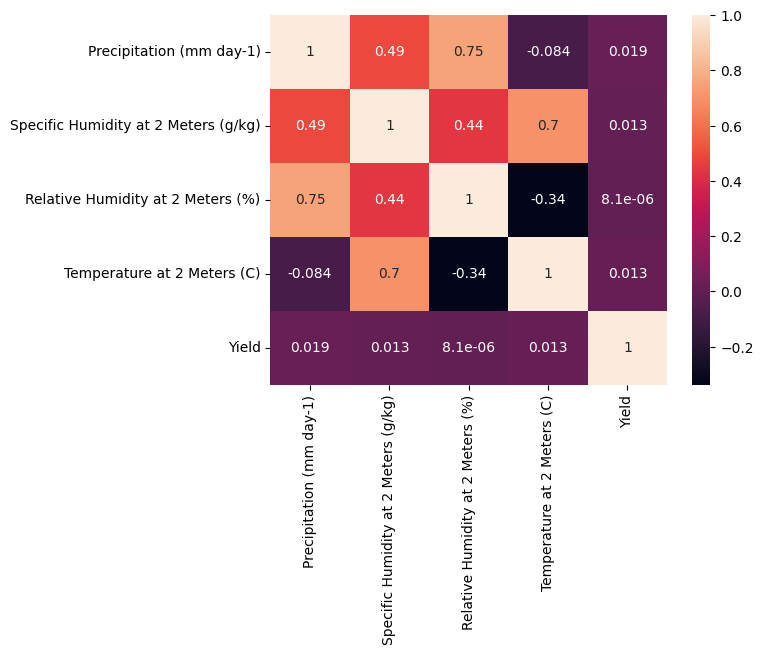

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Heatmap de correlação

O heatmap confirma que não há correlação significativa entre as variáveis climáticas e o rendimento (Yield).

Por outro lado, algumas variáveis climáticas apresentam correlação moderada entre si, como precipitação e umidade.

Isso reforça a ideia de que o rendimento pode depender mais do tipo de cultura do que das variáveis climáticas analisadas.

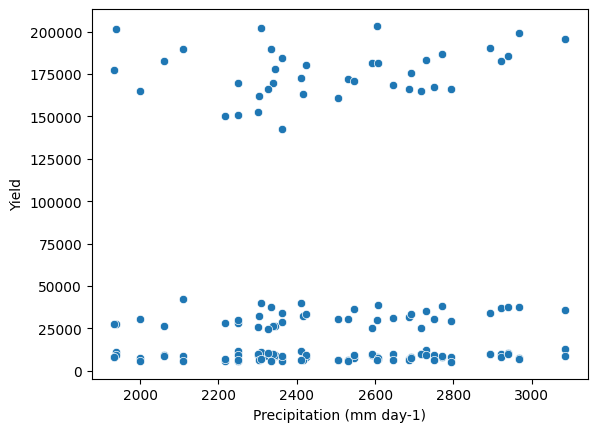

In [17]:
sns.scatterplot(x=df['Precipitation (mm day-1)'], y=df['Yield'])
plt.show()

## Relação entre precipitação e rendimento

O gráfico de dispersão mostra que não há relação clara entre a precipitação e o rendimento (Yield).

Os dados estão bastante dispersos, indicando ausência de padrão.

Também é possível observar dois grupos distintos de rendimento, sugerindo a presença de diferentes comportamentos no dataset.

<Axes: >

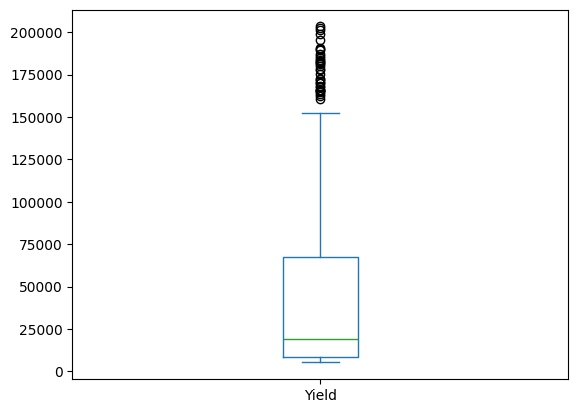

In [18]:
df['Yield'].plot(kind='box')

## Identificação de outliers

O boxplot da variável "Yield" confirma a presença de diversos outliers, principalmente em valores mais altos.

Esses valores extremos podem impactar negativamente o desempenho dos modelos preditivos e devem ser considerados durante o pré-processamento dos dados.

In [19]:
df = df.dropna()

In [20]:
X = df.drop('Yield', axis=1)
y = df['Yield']

## Preparação dos dados

Os dados foram limpos, removendo valores nulos, e separados em variáveis de entrada (X) e variável alvo (y).

In [21]:
X = pd.get_dummies(X, columns=['Crop'])

In [22]:
X.head()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),"Crop_Cocoa, beans",Crop_Oil palm fruit,"Crop_Rice, paddy","Crop_Rubber, natural"
0,2248.92,17.72,83.40,26.01,True,False,False,False
1,1938.42,17.54,82.11,26.11,True,False,False,False
2,2301.54,17.81,82.79,26.24,True,False,False,False
3,2592.35,17.61,85.07,25.56,True,False,False,False
4,2344.72,17.61,84.12,25.76,True,False,False,False


## Tratamento da variável cultura

A variável categórica "Crop" foi convertida em variáveis numéricas utilizando a técnica de one-hot encoding, permitindo seu uso nos modelos de Machine Learning.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
X_train.shape, X_test.shape

((124, 8), (32, 8))

## Divisão dos dados

Os dados foram divididos em conjuntos de treino (80%) e teste (20%), permitindo avaliar o desempenho dos modelos em dados não vistos.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Normalização dos dados

As variáveis foram normalizadas utilizando StandardScaler, garantindo que todas estejam na mesma escala e melhorando o desempenho de alguns modelos de Machine Learning.

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X)

In [27]:
df['Cluster'] = clusters

## Clusterização com K-Means - SEGUNDO PONTO

Foi aplicada a técnica de clusterização K-Means para identificar padrões e agrupamentos nos dados, permitindo analisar possíveis comportamentos distintos entre as observações.

In [29]:
df.groupby('Cluster').mean(numeric_only=True)

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Cluster,,,,,
0,2774.981250,18.319375,85.473125,26.138125,57918.921875
1,2362.791111,18.156667,84.412222,26.208889,54149.500000
2,2008.704000,17.998000,83.556000,26.238000,57715.400000


In [30]:
df['Cluster'].value_counts()

,count
Cluster,
1,72
0,64
2,20


## Análise dos clusters

Os clusters apresentam diferenças nas variáveis climáticas, principalmente na precipitação.

No entanto, o rendimento (Yield) permanece semelhante entre os grupos, indicando que a clusterização não separa claramente cenários de produtividade.

Isso reforça a ideia de que o rendimento não depende fortemente das variáveis climáticas analisadas.

In [31]:
df.sort_values(by='Yield', ascending=False).head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,Cluster
72,Oil palm fruit,2604.59,18.19,83.44,26.43,203399,0
73,Oil palm fruit,2308.51,18.27,83.65,26.47,202379,1
40,Oil palm fruit,1938.42,17.54,82.11,26.11,201436,2
75,Oil palm fruit,2967.41,18.67,85.48,26.46,199074,0
66,Oil palm fruit,3085.79,18.34,86.10,26.03,195523,0


## Identificação de cenários discrepantes - TERCEIRO PONTO

Os maiores valores de rendimento (Yield) estão associados à cultura "Oil palm fruit".

Isso indica que o tipo de cultura tem forte influência sobre o rendimento, sendo um fator mais relevante do que as variáveis climáticas analisadas.

In [32]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

mae, mse, r2

(3132.7963836399663, 19308693.244843192, 0.9950222133854733)

## Avaliação do modelo Linear Regression

O modelo apresentou um excelente desempenho, com R² próximo de 1, indicando alta capacidade de explicação da variabilidade dos dados.

O erro médio absoluto (MAE) foi relativamente baixo em relação à escala do problema, mostrando boas previsões.

No entanto, o resultado muito elevado pode indicar possível overfitting, sendo importante comparar com outros modelos.

In [34]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

In [35]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

mae_dt, mse_dt, r2_dt

(3440.6875, 31813142.25, 0.9917985628726906)

## Avaliação do modelo Decision Tree

O modelo Decision Tree apresentou bom desempenho, com R² elevado, indicando boa capacidade de explicação dos dados.

No entanto, apresentou erro ligeiramente maior em comparação ao modelo de regressão linear, indicando desempenho inferior.

In [36]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [37]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, mse_rf, r2_rf

(2736.387812500001, 22491623.0218969, 0.994201653182963)

## Avaliação do modelo Random Forest

O modelo Random Forest apresentou excelente desempenho, com alto valor de R² e menor erro absoluto médio (MAE) entre os modelos testados.

Isso indica maior precisão nas previsões, tornando-o um dos melhores modelos até o momento.

In [38]:
from sklearn.svm import SVR

model_svr = SVR()
model_svr.fit(X_train, y_train)

y_pred_svr = model_svr.predict(X_test)

In [39]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

mae_svr, mse_svr, r2_svr

(38962.952159090244, 5084089838.971513, -0.31067980761684044)

## Avaliação do modelo SVR

O modelo SVR apresentou desempenho muito ruim, com R² negativo e erro elevado.

Isso indica que o modelo não conseguiu capturar padrões nos dados, sendo inadequado para este problema sem ajustes adicionais.

In [40]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(random_state=42)
model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)

In [41]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

mae_gb, mse_gb, r2_gb

(3066.4084427016423, 36744946.6278027, 0.9905271423003095)

## Comparação dos modelos

Os modelos foram comparados utilizando as métricas MAE, MSE e R².

O modelo Random Forest apresentou o melhor desempenho, com menor erro absoluto médio (MAE) e alto coeficiente de determinação (R²), sendo o mais adequado para o problema.

O modelo SVR apresentou desempenho insatisfatório, enquanto os demais modelos obtiveram bons resultados, porém inferiores ao Random Forest.

In [42]:
resultados = {
    'Modelo': ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR', 'Gradient Boosting'],
    'MAE': [mae, mae_dt, mae_rf, mae_svr, mae_gb],
    'MSE': [mse, mse_dt, mse_rf, mse_svr, mse_gb],
    'R2': [r2, r2_dt, r2_rf, r2_svr, r2_gb]
}

import pandas as pd
df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,MAE,MSE,R2
0,Linear Regression,3132.796384,1.930869e+07,0.995022
1,Decision Tree,3440.687500,3.181314e+07,0.991799
2,Random Forest,2736.387813,2.249162e+07,0.994202
3,SVR,38962.952159,5.084090e+09,-0.310680
4,Gradient Boosting,3066.408443,3.674495e+07,0.990527


## Conclusão - QUARTO PONTO

A análise dos dados mostrou que as variáveis climáticas possuem pouca influência sobre o rendimento das culturas.

O tipo de cultura demonstrou ser um fator mais relevante, com destaque para "Oil palm fruit", que apresentou os maiores valores de rendimento.

Dentre os modelos testados, o Random Forest apresentou o melhor desempenho, sendo o mais indicado para prever o rendimento das safras neste dataset.

O projeto demonstrou a importância da análise exploratória e da comparação entre modelos para escolha da melhor solução.

```
# Isto está formatado como código
```

